# Comparative EDA: Nepali PDF, news, and music lyrics

This notebook compares the three local pretraining sources using the same document units as `scripts/build_pretraining_dataset.py`: one PDF extraction, one news article, and one naturally ordered song. Full row counts come from Parquet metadata. Text-level statistics use reproducible bounded samples so the 1M-row news corpus is not loaded into memory.

In [1]:
from pathlib import Path
import hashlib
import re
import sys
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

SEED = 42
PDF_SAMPLE_SIZE = 5_000
NEWS_SAMPLE_SIZE = 5_000

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'scripts' / 'build_pretraining_dataset.py').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the attentionMaps repository.')

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from scripts.build_pretraining_dataset import iter_lyrics_candidates
from scripts.utils.nepali_text import CleaningConfig, clean_text_with_result, devanagari_letter_stats

PDF_DIR = REPO_ROOT / 'data' / 'raw' / 'nepali_pdf_corpus' / 'data'
NEWS_DIR = REPO_ROOT / 'data' / 'raw' / 'nepali_news_corpus' / 'data'
LYRICS_DIR = REPO_ROOT / 'data' / 'raw' / 'nepali_music_lyrics' / 'archive' / 'Final Dataset'
for path in (PDF_DIR, NEWS_DIR, LYRICS_DIR):
    assert path.is_dir(), f'Dataset not found: {path}'

## Reproducible, memory-bounded Parquet sampling

The sampler draws exact global row positions from all shards, then reads only the row groups containing those positions. This avoids treating the first shard as representative and avoids materializing the full news corpus.

In [2]:
def parquet_layout(data_dir: Path) -> tuple[list[dict], int]:
    files = sorted(data_dir.glob('*.parquet'))
    if not files:
        raise FileNotFoundError(f'No Parquet files found under {data_dir}')
    layout = []
    cursor = 0
    for path in files:
        parquet_file = pq.ParquetFile(path)
        for row_group in range(parquet_file.metadata.num_row_groups):
            rows = parquet_file.metadata.row_group(row_group).num_rows
            layout.append({
                'path': path, 'row_group': row_group,
                'start': cursor, 'stop': cursor + rows, 'rows': rows,
            })
            cursor += rows
    return layout, cursor

def sample_parquet_rows(data_dir: Path, sample_size: int, seed: int) -> tuple[pd.DataFrame, dict]:
    layout, total_rows = parquet_layout(data_dir)
    count = min(sample_size, total_rows)
    selected = np.sort(np.random.default_rng(seed).choice(total_rows, size=count, replace=False))
    pieces = []
    for item in layout:
        left = np.searchsorted(selected, item['start'], side='left')
        right = np.searchsorted(selected, item['stop'], side='left')
        if left == right:
            continue
        offsets = selected[left:right] - item['start']
        table = pq.ParquetFile(item['path']).read_row_group(
            item['row_group'], columns=['id', 'text', 'url']
        )
        pieces.append(table.take(pa.array(offsets, type=pa.int64())))
    frame = pa.concat_tables(pieces).to_pandas()
    metadata = {
        'parquet_files': len({item['path'] for item in layout}),
        'row_groups': len(layout), 'full_documents': total_rows,
        'sampled_documents': len(frame),
    }
    return frame, metadata

In [3]:
pdf, pdf_meta = sample_parquet_rows(PDF_DIR, PDF_SAMPLE_SIZE, SEED)
news, news_meta = sample_parquet_rows(NEWS_DIR, NEWS_SAMPLE_SIZE, SEED + 1)

lyrics_candidates = list(iter_lyrics_candidates(LYRICS_DIR))
lyrics = pd.DataFrame({
    'id': [candidate.source_id for candidate in lyrics_candidates],
    'text': [candidate.text for candidate in lyrics_candidates],
    'url': [candidate.url for candidate in lyrics_candidates],
})
lyrics_input_rows = sum(candidate.metadata['segment_count'] for candidate in lyrics_candidates)
lyrics_source_files = len(list(LYRICS_DIR.glob('*/metadata.csv')))

inventory = pd.DataFrame([
    {
        'corpus': 'PDF', 'source_files': pdf_meta['parquet_files'],
        'input_rows': pdf_meta['full_documents'], 'full_documents': pdf_meta['full_documents'],
        'sampled_documents': pdf_meta['sampled_documents'], 'document_unit': 'PDF extraction',
    },
    {
        'corpus': 'News', 'source_files': news_meta['parquet_files'],
        'input_rows': news_meta['full_documents'], 'full_documents': news_meta['full_documents'],
        'sampled_documents': news_meta['sampled_documents'], 'document_unit': 'news article',
    },
    {
        'corpus': 'Lyrics', 'source_files': lyrics_source_files,
        'input_rows': lyrics_input_rows, 'full_documents': len(lyrics),
        'sampled_documents': len(lyrics), 'document_unit': 'complete song',
    },
]).set_index('corpus')
display(inventory)

,source_files,input_rows,full_documents,sampled_documents,document_unit
corpus,,,,,
PDF,1,8635,8635,5000,PDF extraction
News,18,1006178,1006178,5000,news article
Lyrics,38,3310,105,105,complete song


## Comparable text metrics

The Devanagari ratio is calculated over Unicode letters only, so spaces, punctuation, and digits do not dilute it. Duplicate rates below are exact NFC/whitespace-normalized duplicates within each analysis sample—not an estimate of semantic duplication.

In [4]:
def normalize_for_comparison(text: str) -> str:
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFC', str(text))).strip()

def add_metrics(frame: pd.DataFrame, corpus: str) -> pd.DataFrame:
    result = frame[['id', 'text', 'url']].copy()
    result['corpus'] = corpus
    result['text'] = result['text'].fillna('').astype(str)
    result['normalized'] = result['text'].map(normalize_for_comparison)
    result['characters'] = result['text'].str.len()
    result['utf8_bytes'] = result['text'].map(lambda value: len(value.encode('utf-8')))
    result['whitespace_words'] = result['text'].map(lambda value: len(value.split()))
    result['lines'] = result['text'].map(lambda value: value.count('\n') + 1 if value else 0)
    result['devanagari_ratio'] = result['text'].map(lambda value: devanagari_letter_stats(value)[0])
    result['contains_latin'] = result['text'].str.contains(r'[A-Za-z]', regex=True)
    result['text_hash'] = result['normalized'].map(
        lambda value: hashlib.sha256(value.encode('utf-8')).hexdigest()
    )
    return result

analysis = pd.concat([
    add_metrics(pdf, 'PDF'),
    add_metrics(news, 'News'),
    add_metrics(lyrics, 'Lyrics'),
], ignore_index=True)
assert analysis.groupby('corpus').size().to_dict() == {
    'Lyrics': len(lyrics), 'News': len(news), 'PDF': len(pdf),
}
analysis.head(3)

,id,text,url,corpus,normalized,characters,utf8_bytes,whitespace_words,lines,devanagari_ratio,contains_latin,text_hash
0,002c28866a5ec3907be7349b87132598,Nepal Police Default\nColour Blind\nRed Weakne...,https://cib.nepalpolice.gov.np/news/355/,PDF,Nepal Police Default Colour Blind Red Weakness...,346,760,49,25,0.639024,True,ffc973ebff842e160a23a12e9d4443452db484111c7297...
1,00345ec8615016b33551d57298d922f2,Invitation For Online Sealed Quotation\nअनुदान...,https://babaimun.gov.np/content/%E0%A4%86-%E0%...,PDF,Invitation For Online Sealed Quotation अनुदानम...,1977,4088,353,65,0.722611,True,902d48b26b2c44bc19547cadf07f96d64ff1c45b933f85...
2,003934290b885ded25624fcfd9c5129a,Skip to main content\nFAQs\nComplain\nProblems...,http://www.aanbookhairenimun.gov.np/ne/content...,PDF,Skip to main content FAQs Complain Problems En...,1828,4549,246,78,0.822759,True,dcdfe13d2b1333989b074d714e62ca5b15a1e615e8e5f5...


In [5]:
def summarize(group: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'sample_documents': len(group),
        'characters_median': group['characters'].median(),
        'characters_p95': group['characters'].quantile(.95),
        'characters_p99': group['characters'].quantile(.99),
        'characters_max': group['characters'].max(),
        'words_median': group['whitespace_words'].median(),
        'devanagari_ratio_median': group['devanagari_ratio'].median(),
        'below_80pct_devanagari': group['devanagari_ratio'].lt(.80).mean(),
        'contains_latin': group['contains_latin'].mean(),
        'exact_duplicate_rate_in_sample': group['text_hash'].duplicated().mean(),
    })

summary = analysis.groupby('corpus', sort=False).apply(summarize, include_groups=False)
display(summary.style.format({
    'characters_median': '{:,.0f}', 'characters_p95': '{:,.0f}',
    'characters_p99': '{:,.0f}', 'characters_max': '{:,.0f}',
    'words_median': '{:,.0f}', 'devanagari_ratio_median': '{:.1%}',
    'below_80pct_devanagari': '{:.1%}', 'contains_latin': '{:.1%}',
    'exact_duplicate_rate_in_sample': '{:.1%}',
}))

,sample_documents,characters_median,characters_p95,characters_p99,characters_max,words_median,devanagari_ratio_median,below_80pct_devanagari,contains_latin,exact_duplicate_rate_in_sample
corpus,,,,,,,,,,
PDF,5000.000000,"1,872","31,769","156,522","9,564,648",262,85.3%,35.1%,95.4%,24.5%
News,5000.000000,"1,368","4,966","9,406","249,135",211,100.0%,10.8%,46.4%,1.4%
Lyrics,105.000000,836,"1,308","1,438","1,619",149,100.0%,2.9%,15.2%,0.0%


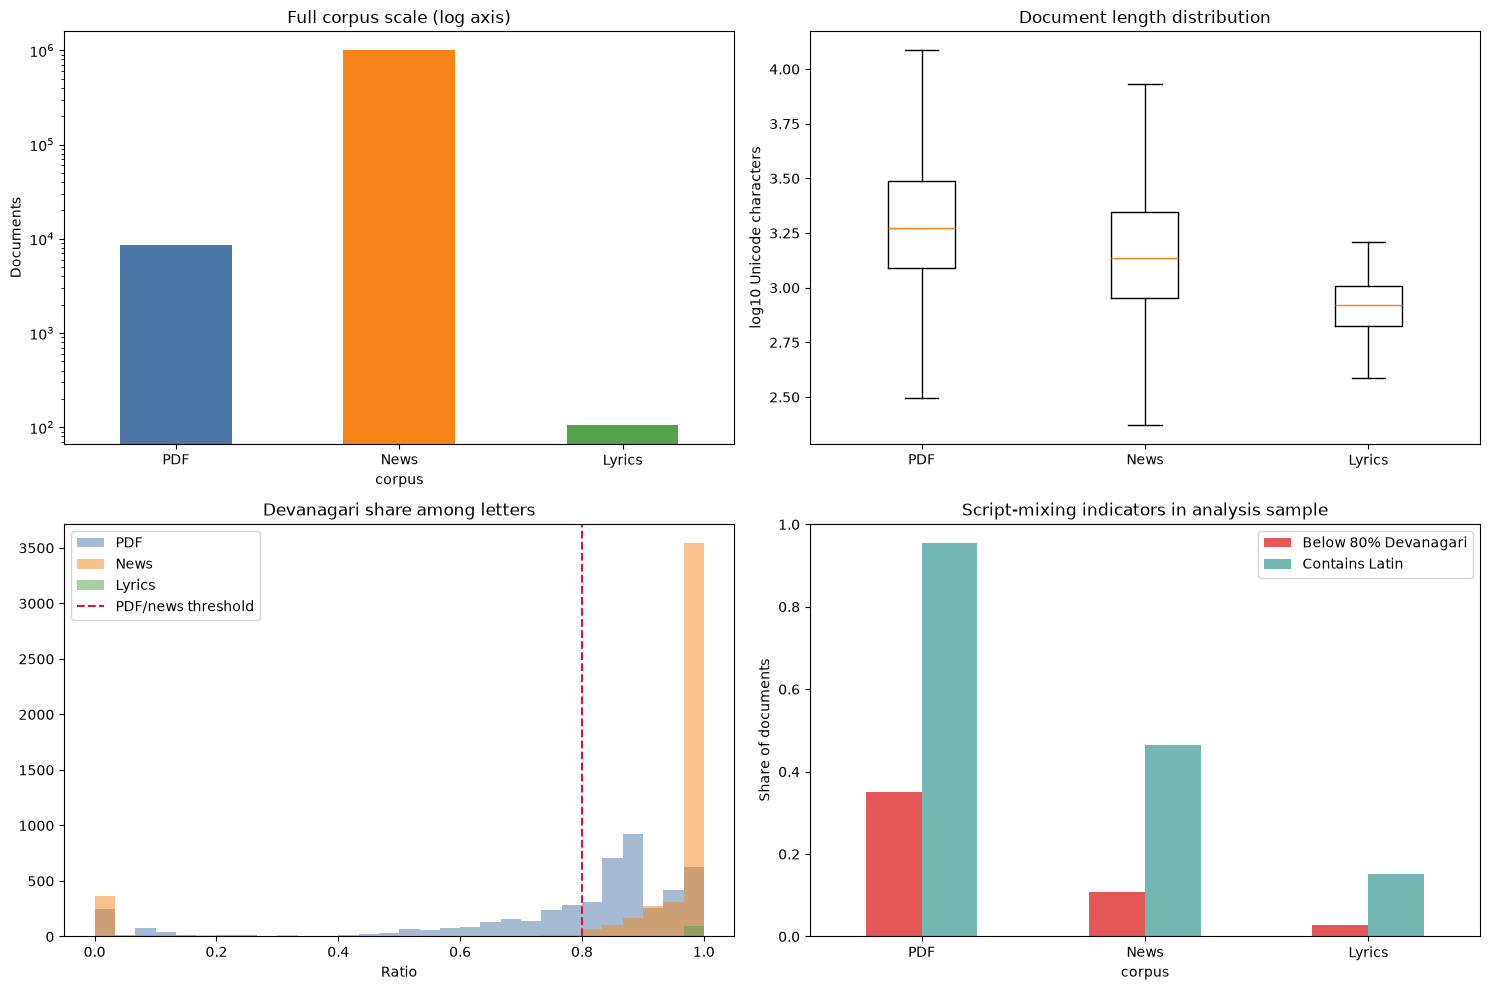

In [6]:
corpus_order = ['PDF', 'News', 'Lyrics']
colors = ['#4c78a8', '#f58518', '#54a24b']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

inventory.loc[corpus_order, 'full_documents'].plot.bar(
    ax=axes[0, 0], color=colors, logy=True
)
axes[0, 0].set_title('Full corpus scale (log axis)')
axes[0, 0].set_ylabel('Documents')
axes[0, 0].tick_params(axis='x', rotation=0)

axes[0, 1].boxplot(
    [np.log10(analysis.loc[analysis['corpus'].eq(name), 'characters'].clip(lower=1)) for name in corpus_order],
    tick_labels=corpus_order, showfliers=False,
)
axes[0, 1].set_title('Document length distribution')
axes[0, 1].set_ylabel('log10 Unicode characters')

for name, color in zip(corpus_order, colors):
    values = analysis.loc[analysis['corpus'].eq(name), 'devanagari_ratio']
    axes[1, 0].hist(values, bins=np.linspace(0, 1, 31), alpha=.5, label=name, color=color)
axes[1, 0].axvline(.80, color='crimson', linestyle='--', label='PDF/news threshold')
axes[1, 0].set_title('Devanagari share among letters')
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].legend()

summary.loc[corpus_order, ['below_80pct_devanagari', 'contains_latin']].plot.bar(
    ax=axes[1, 1], color=['#e45756', '#72b7b2']
)
axes[1, 1].set_title('Script-mixing indicators in analysis sample')
axes[1, 1].set_ylabel('Share of documents')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(['Below 80% Devanagari', 'Contains Latin'])
plt.tight_layout()
plt.show()

## Simulate the shared preprocessing policy

PDF and news use an 80% Nepali-dominance gate. Lyrics use a lower 10% song-level gate so mixed songs retain their Nepali portions. All three then use the strict cleaner, which removes Latin characters and unsupported debris. The table measures acceptance and character retention on the analysis sample.

In [7]:
document_config = CleaningConfig(
    min_devanagari_ratio=.80, min_devanagari_letters=10,
    min_characters=20, mode='strict',
)
lyrics_config = CleaningConfig(
    min_devanagari_ratio=.10, min_devanagari_letters=10,
    min_characters=10, mode='strict',
)

cleaning_rows = []
for row in analysis.itertuples(index=False):
    config = lyrics_config if row.corpus == 'Lyrics' else document_config
    result = clean_text_with_result(row.text, config)
    cleaned, reason = result.text, result.reason
    cleaning_rows.append({
        'corpus': row.corpus, 'accepted': reason is None,
        'reason': reason or 'accepted',
        'input_characters': len(row.text), 'output_characters': len(cleaned),
    })

cleaning = pd.DataFrame(cleaning_rows)
cleaning_summary = cleaning.groupby('corpus').apply(
    lambda group: pd.Series({
        'documents': len(group),
        'accepted': group['accepted'].mean(),
        'character_retention': group['output_characters'].sum() / max(1, group['input_characters'].sum()),
    }),
    include_groups=False,
)
display(cleaning_summary.style.format({'accepted': '{:.1%}', 'character_retention': '{:.1%}'}))
display(pd.crosstab(cleaning['corpus'], cleaning['reason']))

,documents,accepted,character_retention
corpus,,,
Lyrics,105.000000,100.0%,100.0%
News,5000.000000,89.3%,83.4%
PDF,5000.000000,68.5%,74.7%


reason,accepted,low_ratio
corpus,,
Lyrics,105,0
News,4464,536
PDF,3424,1576


## Corpus mixing and size planning

Raw concatenation makes news overwhelmingly dominant. Adjust the example fractions below to preview source sizes; use the corresponding `--pdf-fraction`, `--news-fraction`, and `--lyrics-fraction` flags when building the final Parquet splits. Fractions are deterministic filters, not exact row quotas.

In [8]:
SOURCE_FRACTIONS = {'PDF': 1.0, 'News': 0.01, 'Lyrics': 1.0}
mix = inventory[['full_documents']].copy()
mix['fraction'] = pd.Series(SOURCE_FRACTIONS)
mix['projected_before_cleaning'] = (mix['full_documents'] * mix['fraction']).round().astype(int)
mix['projected_mix_share'] = mix['projected_before_cleaning'] / mix['projected_before_cleaning'].sum()
display(mix.style.format({'fraction': '{:.2%}', 'projected_mix_share': '{:.1%}'}))

print('Equivalent builder arguments:')
print(
    f"--pdf-fraction {SOURCE_FRACTIONS['PDF']} "
    f"--news-fraction {SOURCE_FRACTIONS['News']} "
    f"--lyrics-fraction {SOURCE_FRACTIONS['Lyrics']}"
)

,full_documents,fraction,projected_before_cleaning,projected_mix_share
corpus,,,,
PDF,8635,100.00%,8635,45.9%
News,1006178,1.00%,10062,53.5%
Lyrics,105,100.00%,105,0.6%


Equivalent builder arguments:
--pdf-fraction 1.0 --news-fraction 0.01 --lyrics-fraction 1.0


## What this means for pretraining

- News supplies scale and short-to-medium factual prose, but will dominate training unless sampled or weighted.
- PDF text adds longer documents and broader formal domains; its long tail makes sequence packing important.
- Lyrics is a very small, repetitive, stylistically distinct source. Keep song boundaries, apply the lower pre-cleaning language gate, and control its influence explicitly rather than relying on raw row counts.
- Apply source-aware cleaning first, then exact cross-source deduplication, then deterministic train/validation/test assignment. This prevents duplicates from leaking across splits.
- Re-run this notebook after adding a new corpus so schema, document unit, language gate, scale, and sampling weight are decided before training.